In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

eeo_df = pd.read_csv('data/eeo_all_data.csv')
growth_df = pd.read_csv('data/eeo_growth_data.csv')

condition_map = {2: 'DMSO',
                 3: 'IL1B',
                 4: 'Bent',
                 5: '3013',
                 8: 'DMSO',
                 9: 'IL1B',
                 10: 'Bent',
                 11: '3013'}

eeo_df['drug_condition'] = eeo_df['well_id'].apply(lambda well: condition_map[int(well[1:])])
growth_df['drug_condition'] = growth_df['well_id'].apply(lambda well: condition_map[int(well[1:])])

culture_map = {2: 'tri',
               3: 'tri',
               4: 'tri',
               5: 'tri',
               8: 'mono',
               9: 'mono',
               10: 'mono',
               11: 'mono'}

eeo_df['culture_type'] = np.where(eeo_df['culture_thingy'] == 'co', 'co', eeo_df['well_id'].apply(lambda well: culture_map[int(well[1:])]))
growth_df['culture_type'] = np.where(growth_df['culture_thingy'] == 'co', 'co', growth_df['well_id'].apply(lambda well: culture_map[int(well[1:])]))

eeo_df = eeo_df.drop(columns=['track_id', 'culture_thingy', 'Unnamed: 0'])
growth_df = growth_df.drop(columns=['track_id', 'culture_thingy', 'Unnamed: 0'])

In [112]:
eeo_df

,centroid_y,centroid_x,area,eccentricity,solidity,perimeter,circularity,intensity_std,equiv_diameter,t,well_id,donor,drug_condition,culture_type
0,174.235771,488.982966,14442.0,0.069813,0.991351,446.617316,0.909842,0.0,135.602823,0,B02,284,DMSO,tri
1,218.250337,287.791827,20752.0,0.441191,0.959541,570.913780,0.800071,0.0,162.549276,0,B02,284,DMSO,tri
2,202.035540,631.530067,15166.0,0.621426,0.919542,504.759451,0.748018,0.0,138.960249,0,B02,284,DMSO,tri
3,676.169623,777.483370,902.0,0.437575,0.974082,110.083261,0.935349,0.0,33.888967,0,B02,284,DMSO,tri
4,754.361751,629.725230,3472.0,0.601248,0.980237,222.450793,0.881702,0.0,66.488252,0,B02,284,DMSO,tri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14219,437.488372,579.511628,43.0,0.845135,0.895833,24.727922,0.883696,0.0,7.399277,4,F04,304,Bent,co
14220,469.357599,648.545338,783.0,0.810844,0.966667,108.325902,0.838508,0.0,31.574461,4,F04,304,Bent,co
14221,460.630435,578.108696,46.0,0.503160,1.000000,21.899495,1.205312,0.0,7.653040,4,F04,304,Bent,co
14222,480.220339,491.101695,59.0,0.568976,0.967213,25.899495,1.105298,0.0,8.667245,4,F04,304,Bent,co


In [113]:
growth_df

,n_timepoints,t_start,t_end,diameter_start,diameter_end,diameter_growth_rate,area_start,area_end,area_growth_rate,had_merge,well_id,donor,drug_condition,culture_type
0,5.0,0.0,4.0,33.888967,55.897494,5.627809,902.0,1420.0,404.1,False,B02,284,DMSO,tri
1,5.0,0.0,4.0,66.488252,66.813007,0.664816,3472.0,3643.0,73.8,False,B02,284,DMSO,tri
2,5.0,0.0,4.0,65.329159,88.324055,6.055717,3352.0,4140.0,737.8,False,B03,284,IL1B,tri
3,4.0,1.0,4.0,62.418851,74.455926,3.642827,3060.0,4086.0,391.8,False,B03,284,IL1B,tri
4,5.0,0.0,4.0,102.446638,182.057606,19.472942,8243.0,12473.0,4359.7,False,B04,284,Bent,tri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,3.0,0.0,2.0,31.875463,35.521548,1.823042,798.0,1158.0,96.5,True,E04,304,Bent,co
830,4.0,1.0,4.0,41.810978,42.655121,0.226350,1373.0,1435.0,15.0,False,E04,304,Bent,co
831,4.0,1.0,4.0,49.776743,74.207554,8.958737,1946.0,1742.0,855.1,False,E04,304,Bent,co
832,3.0,2.0,4.0,67.589818,126.111202,29.260692,3588.0,6826.0,4451.5,False,E04,304,Bent,co


In [115]:
culture_order = ['mono', 'co', 'tri']
drug_order = ['DMSO', 'IL1B', 'Bent', '3013']

#df = df[~df['had_merge']]
donor_means = growth_df.groupby(by=['donor', 'drug_condition', 'culture_type'])[['diameter_start', 'diameter_end', 'diameter_growth_rate', 'area_start', 'area_end', 'area_growth_rate']].mean().reset_index()

C:\Users\jaked\AppData\Local\Temp\ipykernel_42224\2285523446.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y='area_growth_rate', order=drug_order,


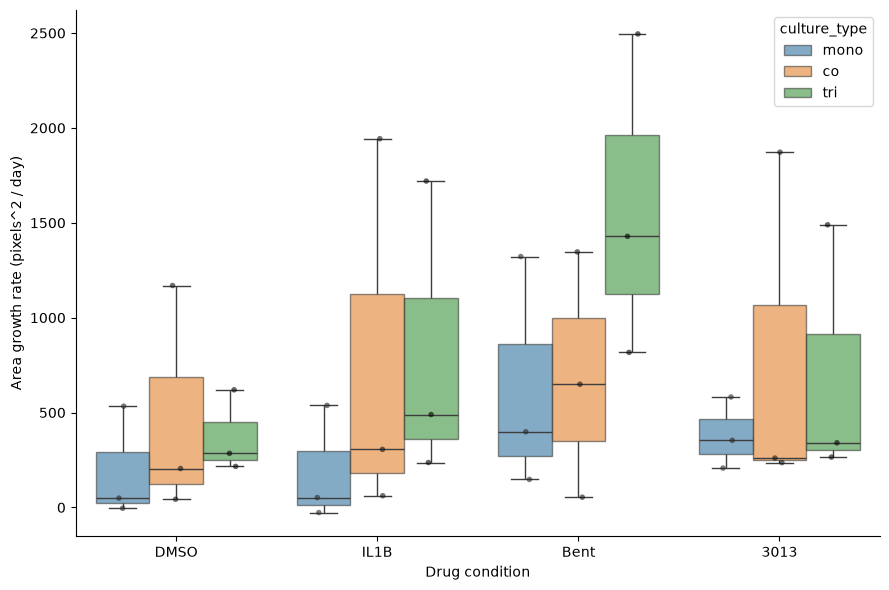

In [116]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(donor_means, x='drug_condition', y='area_growth_rate', order=drug_order,
            hue='culture_type', hue_order=culture_order, showfliers=False,
            boxprops=dict(alpha=0.6), ax=ax)

sns.stripplot(donor_means, x='drug_condition', y='area_growth_rate', order=drug_order,
              hue='culture_type', hue_order=culture_order, dodge=True, jitter=True,
              color='k', size=4, alpha=0.6, legend=False, ax=ax)

ax.set_xlabel('Drug condition')
ax.set_ylabel('Area growth rate (pixels^2 / day)')

sns.despine()
plt.tight_layout()
plt.show()

C:\Users\jaked\AppData\Local\Temp\ipykernel_42224\2054500614.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(donor_means, x='drug_condition', y='area_end', order=drug_order,


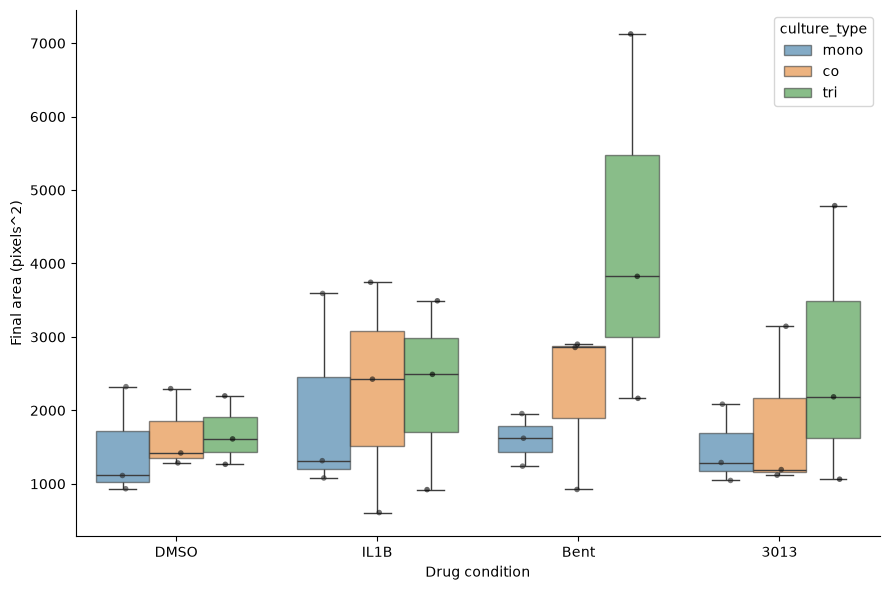

In [117]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(donor_means, x='drug_condition', y='area_end', order=drug_order,
            hue='culture_type', hue_order=culture_order, showfliers=False,
            boxprops=dict(alpha=0.6), ax=ax)

sns.stripplot(donor_means, x='drug_condition', y='area_end', order=drug_order,
              hue='culture_type', hue_order=culture_order, dodge=True, jitter=True,
              color='k', size=4, alpha=0.6, legend=False, ax=ax)

ax.set_xlabel('Drug condition')
ax.set_ylabel('Final area (pixels^2)')

sns.despine()
plt.tight_layout()
plt.show()

In [120]:
eeo_df

,centroid_y,centroid_x,area,eccentricity,solidity,perimeter,circularity,intensity_std,equiv_diameter,t,well_id,donor,drug_condition,culture_type
0,174.235771,488.982966,14442.0,0.069813,0.991351,446.617316,0.909842,0.0,135.602823,0,B02,284,DMSO,tri
1,218.250337,287.791827,20752.0,0.441191,0.959541,570.913780,0.800071,0.0,162.549276,0,B02,284,DMSO,tri
2,202.035540,631.530067,15166.0,0.621426,0.919542,504.759451,0.748018,0.0,138.960249,0,B02,284,DMSO,tri
3,676.169623,777.483370,902.0,0.437575,0.974082,110.083261,0.935349,0.0,33.888967,0,B02,284,DMSO,tri
4,754.361751,629.725230,3472.0,0.601248,0.980237,222.450793,0.881702,0.0,66.488252,0,B02,284,DMSO,tri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14219,437.488372,579.511628,43.0,0.845135,0.895833,24.727922,0.883696,0.0,7.399277,4,F04,304,Bent,co
14220,469.357599,648.545338,783.0,0.810844,0.966667,108.325902,0.838508,0.0,31.574461,4,F04,304,Bent,co
14221,460.630435,578.108696,46.0,0.503160,1.000000,21.899495,1.205312,0.0,7.653040,4,F04,304,Bent,co
14222,480.220339,491.101695,59.0,0.568976,0.967213,25.899495,1.105298,0.0,8.667245,4,F04,304,Bent,co


In [153]:
(eeo_df['area'] < 20).sum()

np.int64(396)

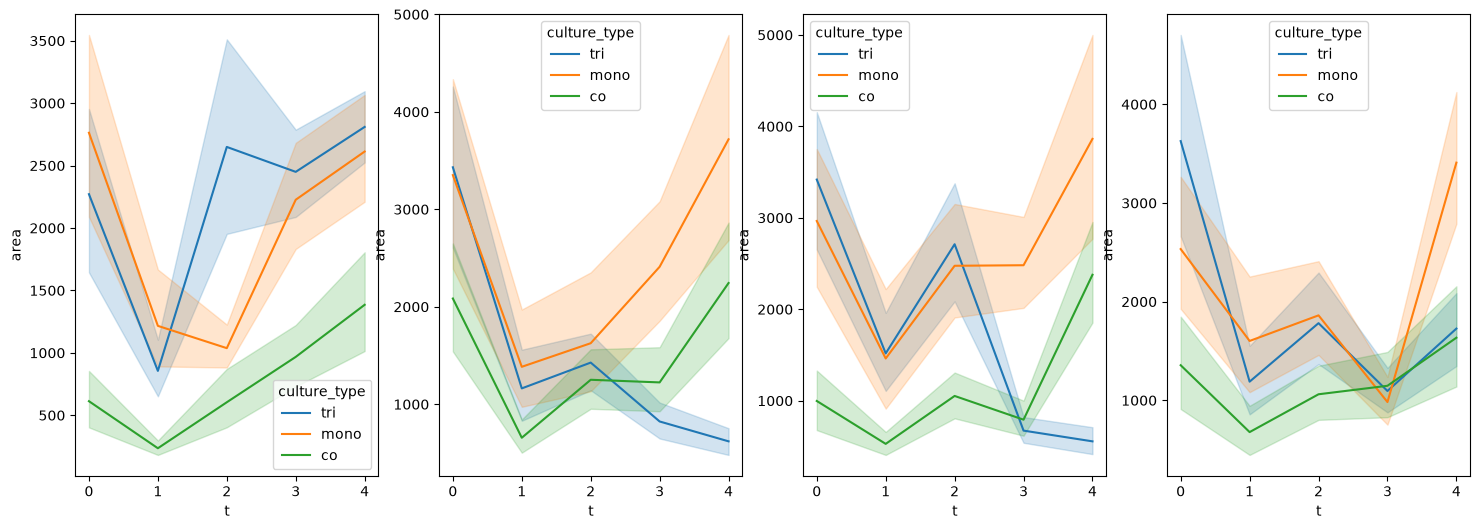

In [156]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6))
axs = axs.ravel()

for ax, drug in zip(axs, drug_order):
    filter = (eeo_df['drug_condition'] == drug) & (eeo_df['area'] > 20)
    sns.lineplot(eeo_df[filter], x='t', y='area', hue='culture_type', ax=ax)

<Axes: xlabel='PC1', ylabel='PC2'>

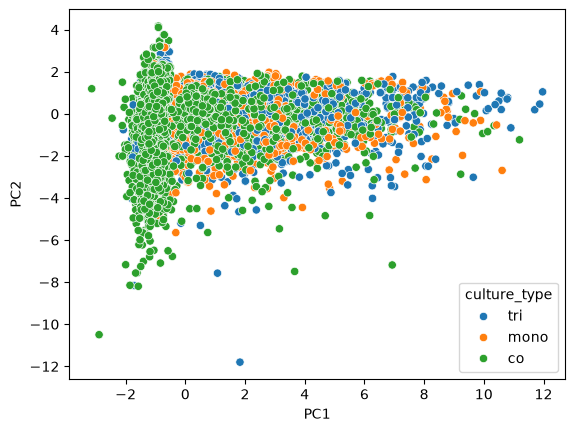

In [168]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ['area', 'eccentricity', 'solidity', 'perimeter', 'circularity', 'intensity_std', 'equiv_diameter']

X = eeo_df[features]
X = StandardScaler().fit_transform(X)
pca = PCA(n_components=2).fit(X)

results = pca.transform(X)

pca_df = pd.DataFrame(results, columns=['PC1', 'PC2'])
pca_df['drug_condition'] = eeo_df['drug_condition']
pca_df['culture_type'] = eeo_df['culture_type']

sns.scatterplot(pca_df, x='PC1', y='PC2', hue='culture_type')

In [171]:
print(pca.components_)

[[ 0.52909736 -0.13178644  0.19612991  0.55384067 -0.21653055  0.04122324
   0.55578507]
 [-0.02373388 -0.56929996  0.56309048 -0.05559658  0.5838772  -0.11781331
  -0.01948923]]


Text(0.5, 1.0, 'PC2 loadings')

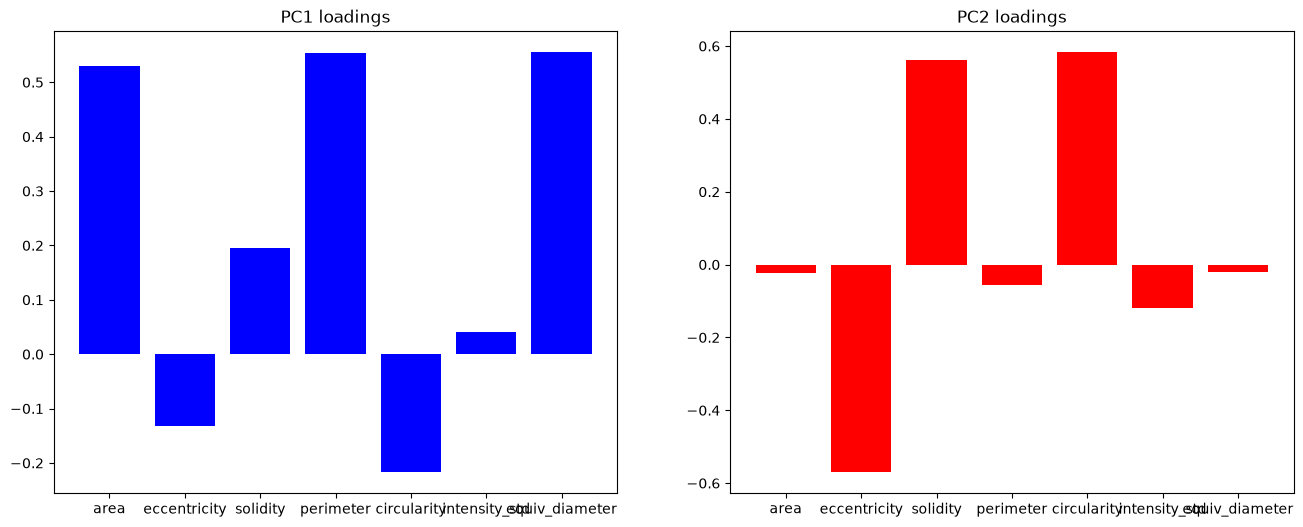

In [190]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].bar(x=features, height=pca.components_[0], color='blue')
axs[0].set_title('PC1 loadings')

axs[1].bar(x=features, height=pca.components_[1], color='red')
axs[1].set_title('PC2 loadings')

In [192]:
from sklearn.manifold import TSNE

tsne = TSNE().fit(X)
results = tsne.transform(X)

AttributeError: 'TSNE' object has no attribute 'transform'

In [ ]:
print(results.embedding_)